In [132]:
# First let's import the packages we will use in this project
# You can do this all now or as you need them
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib
plt.style.use('ggplot')
from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8)

pd.options.mode.chained_assignment = None



# Now we need to read in the data
df = pd.read_csv(r'movies.csv')

In [133]:
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [134]:
for col in df.columns:
  pct_missing = np.mean(df[col].isnull())
  print('{} - {}%'.format(col, round(pct_missing*100)))

name - 0%
rating - 1%
genre - 0%
year - 0%
released - 0%
score - 0%
votes - 0%
director - 0%
writer - 0%
star - 0%
country - 0%
budget - 28%
gross - 2%
company - 0%
runtime - 0%


In [135]:
print(df.dtypes)

name         object
rating       object
genre        object
year          int64
released     object
score       float64
votes       float64
director     object
writer       object
star         object
country      object
budget      float64
gross       float64
company      object
runtime     float64
dtype: object


In [136]:
df = df.dropna()

In [137]:
# Change data types to remove decimals from currency
df['budget'] = df['budget'].astype('int64')
df['gross'] = df['gross'].astype('int64')

In [138]:
# Create a 'yearcorrect' column by extracting the first 4 characters from 'released'
df['yearcorrect'] = df['released'].str.extract(r'(\d{4})')

In [139]:
df

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,yearcorrect
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146.0,1980
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104.0,1980
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124.0,1980
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88.0,1980
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98.0,1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7648,Bad Boys for Life,R,Action,2020,"January 17, 2020 (United States)",6.6,140000.0,Adil El Arbi,Peter Craig,Will Smith,United States,90000000,426505244,Columbia Pictures,124.0,2020
7649,Sonic the Hedgehog,PG,Action,2020,"February 14, 2020 (United States)",6.5,102000.0,Jeff Fowler,Pat Casey,Ben Schwartz,United States,85000000,319715683,Paramount Pictures,99.0,2020
7650,Dolittle,PG,Adventure,2020,"January 17, 2020 (United States)",5.6,53000.0,Stephen Gaghan,Stephen Gaghan,Robert Downey Jr.,United States,175000000,245487753,Universal Pictures,101.0,2020
7651,The Call of the Wild,PG,Adventure,2020,"February 21, 2020 (United States)",6.8,42000.0,Chris Sanders,Michael Green,Harrison Ford,Canada,135000000,111105497,20th Century Studios,100.0,2020


In [140]:
# Sort the data by gross revenue
df = df.sort_values(by=['gross'], inplace=False, ascending=False)

In [141]:
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,yearcorrect
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162.0,2009
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0,2019
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194.0,1997
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138.0,2015
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149.0,2018


In [142]:
df.drop_duplicates()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,yearcorrect
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162.0,2009
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0,2019
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194.0,1997
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138.0,2015
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149.0,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5640,Tanner Hall,R,Drama,2009,"January 15, 2015 (Sweden)",5.8,3500.0,Francesca Gregorini,Tatiana von Fürstenberg,Rooney Mara,United States,3000000,5073,Two Prong Lesson,96.0,2015
2434,Philadelphia Experiment II,PG-13,Action,1993,"June 4, 1994 (South Korea)",4.5,1900.0,Stephen Cornwell,Wallace C. Bennett,Brad Johnson,United States,5000000,2970,Trimark Pictures,97.0,1994
3681,Ginger Snaps,Not Rated,Drama,2000,"May 11, 2001 (Canada)",6.8,43000.0,John Fawcett,Karen Walton,Emily Perkins,Canada,5000000,2554,Copperheart Entertainment,108.0,2001
272,Parasite,R,Horror,1982,"March 12, 1982 (United States)",3.9,2300.0,Charles Band,Alan J. Adler,Robert Glaudini,United States,800000,2270,Embassy Pictures,85.0,1982


<Axes: >

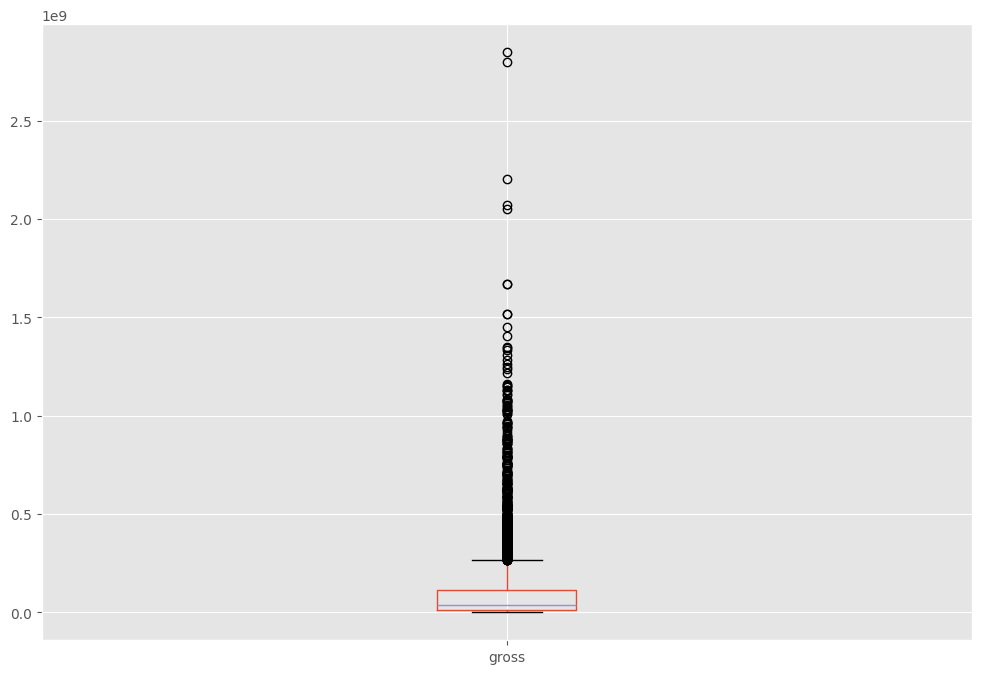

In [143]:
# Are there any Outliers?

df.boxplot(column=['gross'])

<function matplotlib.pyplot.show(close=None, block=None)>

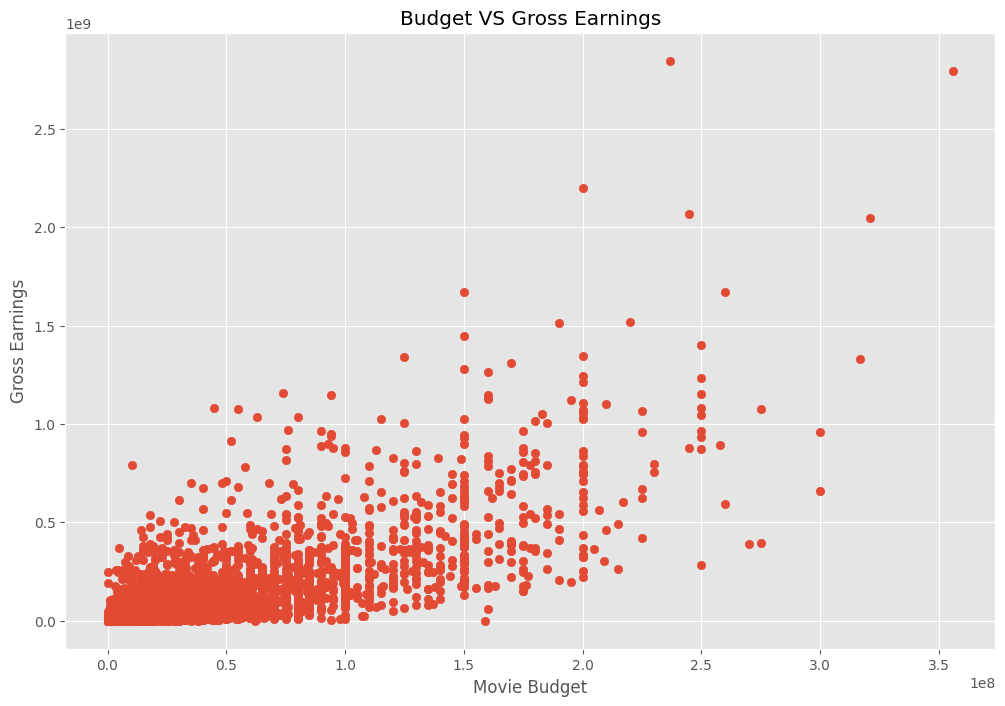

In [144]:
# Create a scatter plot to show relationship between budget and gross
plt.scatter(x=df['budget'],y=df['gross'])
plt.title('Budget VS Gross Earnings')
plt.xlabel ('Movie Budget')
plt.ylabel ('Gross Earnings')
plt.show

<Axes: xlabel='budget', ylabel='gross'>

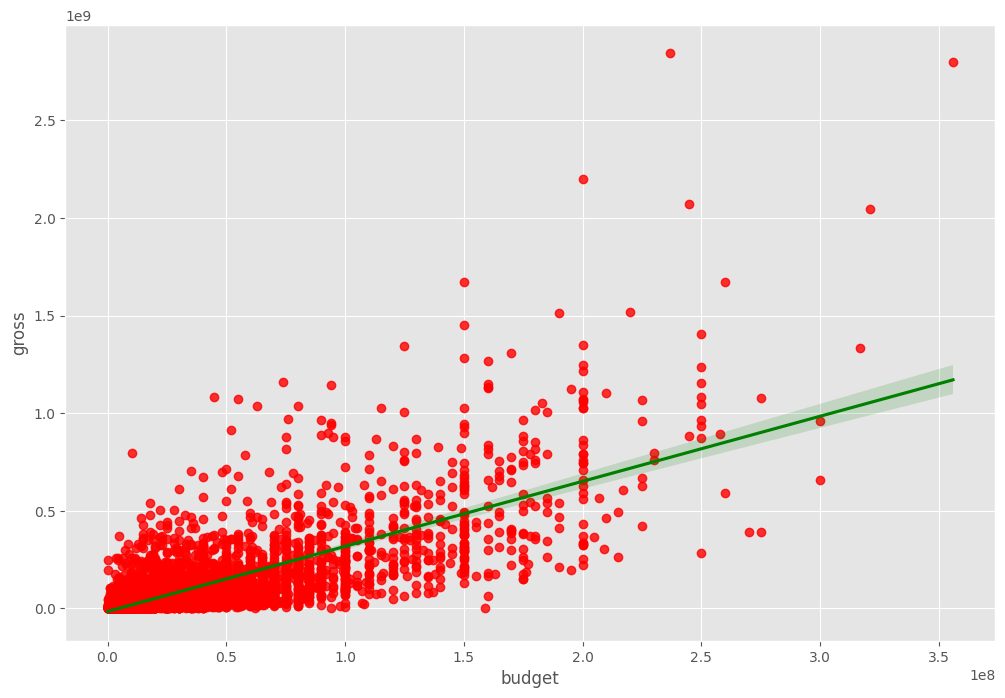

In [145]:
# Plot budget vs gross using seaborn
sns.regplot(x=df['budget'], y=df['gross'], scatter_kws={'color': 'red'}, line_kws={'color': 'green'})

In [146]:
# Look at correlation between budget and gross
df[['budget', 'gross']].corr(method='pearson')# Pearson

,budget,gross
budget,1.000000,0.740247
gross,0.740247,1.000000


In [147]:
df[['budget', 'gross']].corr(method='kendall')# Kendall


,budget,gross
budget,1.000000,0.512057
gross,0.512057,1.000000


In [148]:
df[['budget', 'gross']].corr(method='spearman')# Spearman


,budget,gross
budget,1.000000,0.692958
gross,0.692958,1.000000


In [149]:
# Budget has a high correlation with gross revenue - Right!


In [150]:
# Look at correlation between numerical features
df.select_dtypes(include=['int64', 'float64']).corr()


,year,score,votes,budget,gross,runtime
year,1.000000,0.056386,0.206021,0.327722,0.274321,0.075077
score,0.056386,1.000000,0.474256,0.072001,0.222556,0.414068
votes,0.206021,0.474256,1.000000,0.439675,0.614751,0.352303
budget,0.327722,0.072001,0.439675,1.000000,0.740247,0.318695
gross,0.274321,0.222556,0.614751,0.740247,1.000000,0.275796
runtime,0.075077,0.414068,0.352303,0.318695,0.275796,1.000000


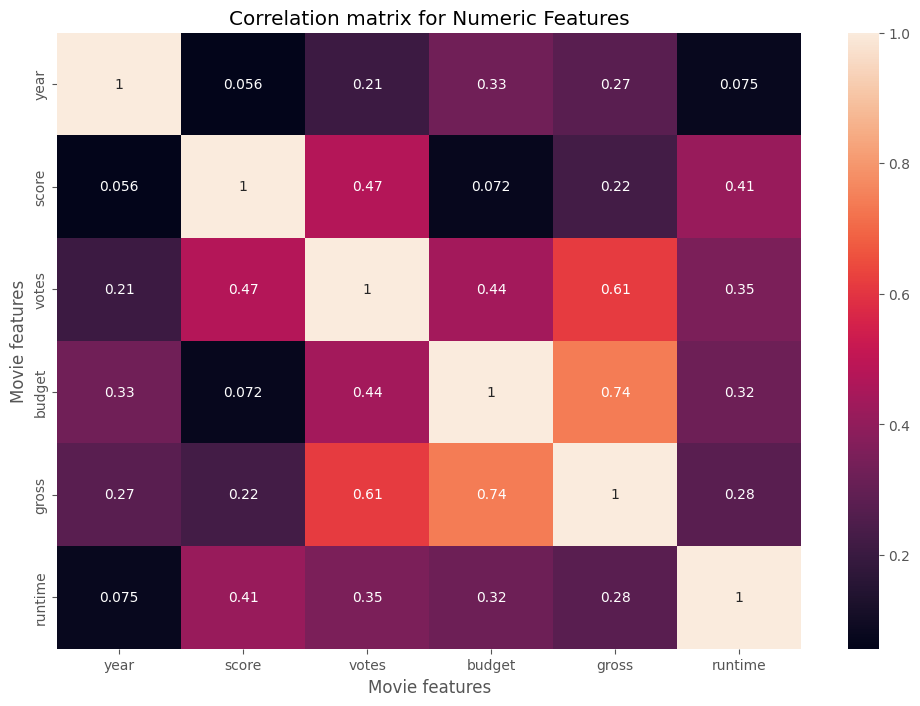

In [151]:
# Create a Correlation Heatmap of Movie Features
correlation_matrix=df.select_dtypes(include=['int64', 'float64']).corr(method='pearson')
sns.heatmap(data=correlation_matrix,annot=True)
plt.title("Correlation matrix for Numeric Features")
plt.xlabel("Movie features")
plt.ylabel("Movie features")
plt.show()

In [152]:
# 2. Look at Company with gross revenue


In [153]:
df.head()


,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,yearcorrect
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162.0,2009
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0,2019
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194.0,1997
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138.0,2015
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149.0,2018


In [154]:
# Change the objects to categories
df_numerized = df.copy()
for col_name in df_numerized.columns:
    if(df_numerized[col_name].dtype == 'object'):
        df_numerized[col_name] = df_numerized[col_name].astype('category')
        df_numerized[col_name] = df_numerized[col_name].cat.codes# Convert categorical strings to numerical codes
df_numerized.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,yearcorrect
5445,386,5,0,2009,527,7.8,1100000.0,785,1263,1534,47,237000000,2847246203,1382,162.0,29
7445,388,5,0,2019,137,8.4,903000.0,105,513,1470,47,356000000,2797501328,983,181.0,39
3045,4909,5,6,1997,534,7.8,1100000.0,785,1263,1073,47,200000000,2201647264,1382,194.0,17
6663,3643,5,0,2015,529,7.8,876000.0,768,1806,356,47,245000000,2069521700,945,138.0,35
7244,389,5,0,2018,145,8.4,897000.0,105,513,1470,47,321000000,2048359754,983,149.0,38


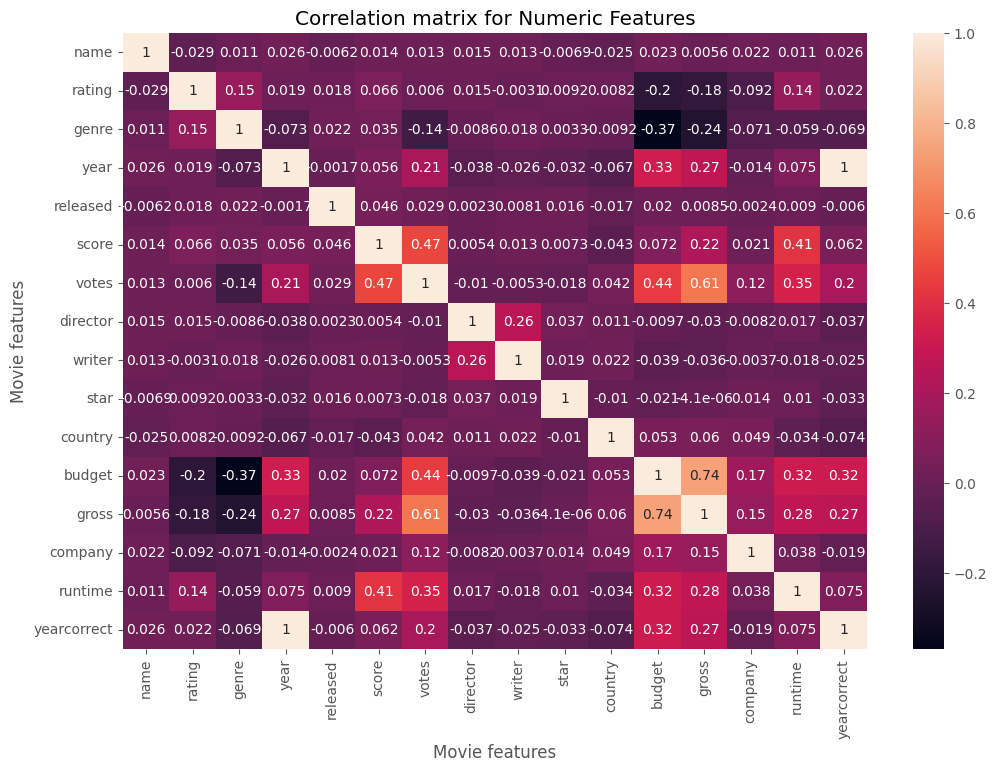

In [155]:
# Create a Correlation Heatmap of Movie Features
correlation_matrix=df_numerized.corr(method='pearson')
sns.heatmap(data=correlation_matrix,annot=True)
plt.title("Correlation matrix for Numeric Features")
plt.xlabel("Movie features")
plt.ylabel("Movie features")
plt.show()

In [156]:
df_numerized.corr(method='pearson')


,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,yearcorrect
name,1.000000,-0.029234,0.010996,0.025542,-0.006152,0.014450,0.012615,0.015246,0.012880,-0.006882,-0.025490,0.023392,0.005639,0.021697,0.010850,0.025542
rating,-0.029234,1.000000,0.147796,0.019499,0.018083,0.065983,0.006031,0.014656,-0.003149,0.009196,0.008230,-0.203946,-0.181906,-0.092357,0.140792,0.022021
genre,0.010996,0.147796,1.000000,-0.073167,0.022142,0.035106,-0.135990,-0.008553,0.017578,0.003341,-0.009164,-0.368523,-0.244101,-0.071334,-0.059237,-0.069147
year,0.025542,0.019499,-0.073167,1.000000,-0.001740,0.056386,0.206021,-0.038354,-0.025908,-0.032157,-0.066748,0.327722,0.274321,-0.014333,0.075077,0.998726
released,-0.006152,0.018083,0.022142,-0.001740,1.000000,0.045874,0.028833,0.002308,0.008072,0.015706,-0.017228,0.019952,0.008501,-0.002407,0.008975,-0.005989
score,0.014450,0.065983,0.035106,0.056386,0.045874,1.000000,0.474256,0.005413,0.012843,0.007296,-0.043051,0.072001,0.222556,0.020656,0.414068,0.061923
votes,0.012615,0.006031,-0.135990,0.206021,0.028833,0.474256,1.000000,-0.010376,-0.005316,-0.017638,0.041551,0.439675,0.614751,0.118470,0.352303,0.203098
director,0.015246,0.014656,-0.008553,-0.038354,0.002308,0.005413,-0.010376,1.000000,0.261735,0.036593,0.011133,-0.009662,-0.029560,-0.008223,0.017433,-0.037371
writer,0.012880,-0.003149,0.017578,-0.025908,0.008072,0.012843,-0.005316,0.261735,1.000000,0.018520,0.022488,-0.039466,-0.035885,-0.003697,-0.017561,-0.025495
star,-0.006882,0.009196,0.003341,-0.032157,0.015706,0.007296,-0.017638,0.036593,0.018520,1.000000,-0.009990,-0.021473,-0.000004,0.014082,0.010108,-0.032687


In [157]:
# Turn a square matrix into a long, flat table / a long list of pairs.
correlation_mat = df_numerized.corr(method='pearson')
corr_pairs = correlation_mat.unstack()
corr_pairs

name         name           1.000000
             rating        -0.029234
             genre          0.010996
             year           0.025542
             released      -0.006152
                              ...   
yearcorrect  budget         0.320312
             gross          0.268721
             company       -0.018806
             runtime        0.075294
             yearcorrect    1.000000
Length: 256, dtype: float64

In [158]:
corr_pairs[('company', 'gross')]


np.float64(0.14955258753405165)

In [159]:
# Company has a high correlation with gross revenue - Wrong!


In [160]:
corr_pairs[('budget', 'gross')]


np.float64(0.7402465439219614)

In [161]:
sorted_pairs = corr_pairs.sort_values()
sorted_pairs

,,0
genre,budget,-0.368523
budget,genre,-0.368523
gross,genre,-0.244101
genre,gross,-0.244101
rating,budget,-0.203946
...,...,...
star,star,1.000000
company,company,1.000000
gross,gross,1.000000
runtime,runtime,1.000000


In [162]:
# High correlations (greater than 0.5)
high_corr = sorted_pairs[(sorted_pairs > 0.5) & (sorted_pairs < 1.0)]
high_corr

,,0
gross,votes,0.614751
votes,gross,0.614751
gross,budget,0.740247
budget,gross,0.740247
year,yearcorrect,0.998726
yearcorrect,year,0.998726


In [163]:
# High correlations with gross
high_corr['gross']

,0
votes,0.614751
budget,0.740247


In [164]:
# Conclusion:
# 1. Budget has the strongest correlation with gross earnings at 0.740.
# 2. Votes (number of audience ratings) also shows a high correlation at 0.615.
# 3. Higher budget and greater audience engagement tend to lead to higher box office revenue

In [165]:
# Looking at the top 15 compaies by gross revenue

CompanyGrossSum = df.groupby('company')[["gross"]].sum()

CompanyGrossSumSorted = CompanyGrossSum.sort_values('gross', ascending = False)[:15]

CompanyGrossSumSorted = CompanyGrossSumSorted['gross'].astype('int64')

CompanyGrossSumSorted

,gross
company,
Warner Bros.,54610959970
Universal Pictures,51241105418
Columbia Pictures,42356430218
Paramount Pictures,40021704691
Twentieth Century Fox,39542573303
Walt Disney Pictures,35833650748
New Line Cinema,19612851164
Marvel Studios,15065592411
DreamWorks Animation,11873612858


In [166]:
print(CompanyGrossSumSorted.index[0])

Warner Bros.


In [167]:
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,yearcorrect
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162.0,2009
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0,2019
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194.0,1997
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138.0,2015
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149.0,2018


In [172]:
df.groupby(['company', 'yearcorrect'])[["gross"]].sum().sort_values('gross', ascending=False)[:10]

,,gross
company,yearcorrect,
Walt Disney Pictures,2019,5773131804
Marvel Studios,2018,4018631866
Universal Pictures,2015,3834354888
Twentieth Century Fox,2009,3793491246
Walt Disney Pictures,2017,3789382071
Paramount Pictures,2011,3565705182
Warner Bros.,2011,3168551343
Walt Disney Pictures,2010,3104474158
Paramount Pictures,2014,3071298586



--- Impact of Movie Rating on Gross Revenue ---
                  gross
rating                 
PG-13      266542294450
R          145199814244
PG         124929793534
G           21006223173
Not Rated     944428241
TV-MA         700083289
NC-17         191307081
Unrated        40255080
Approved       36565280
X              17186348


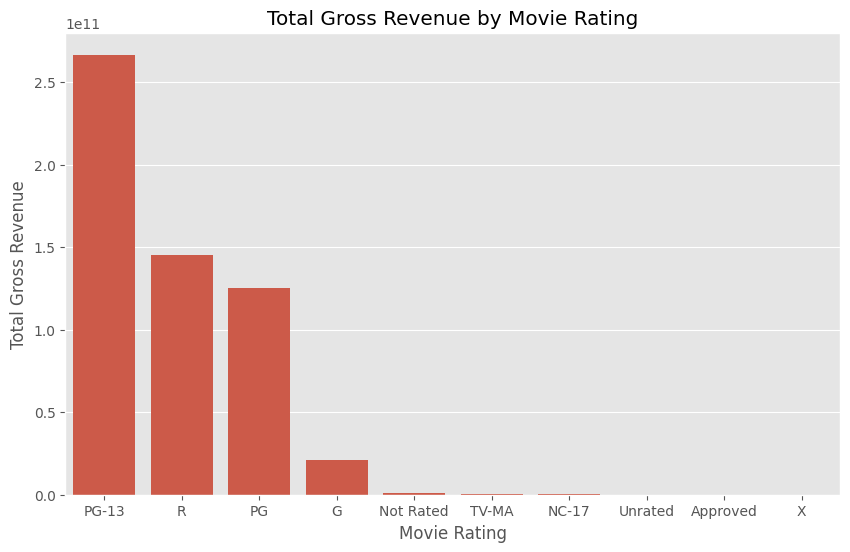

In [ ]:
print('\n--- Impact of Movie Rating on Gross Revenue ---')
rating_gross = df.groupby('rating')[['gross']].sum().sort_values(by='gross', ascending=False)
print(rating_gross)

plt.figure(figsize=(10, 6))
sns.barplot(x=rating_gross.index, y=rating_gross['gross'])
plt.title('Total Gross Revenue by Movie Rating')
plt.xlabel('Movie Rating')
plt.ylabel('Total Gross Revenue')
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 83.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 77.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 22.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 93.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 63.6% of the points cannot be plac

<Axes: xlabel='rating', ylabel='gross'>

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 77.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


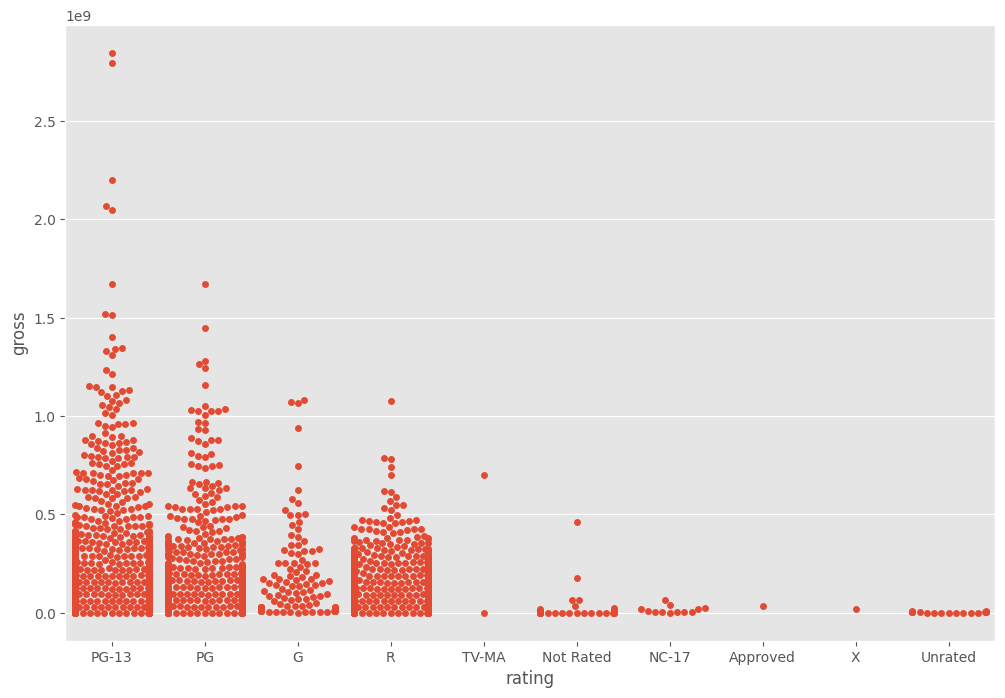

In [171]:
sns.swarmplot(x="rating", y="gross", data=df)

In [ ]:
grouped_movies = df.groupby('yearcorrect')
grouped_movies_mean = grouped_movies['score'].mean()
grouped_movies_mean
grouped_movies_mean_sorted = grouped_movies_mean.sort_values(ascending=False)
grouped_movies_mean_sorted

,score
yearcorrect,
2020,6.827273
2016,6.616456
2014,6.588199
2013,6.544720
2007,6.502424
2019,6.500826
2018,6.488194
1980,6.483333
2015,6.477914


In [ ]:
highest_rated_movie = df.sort_values(by='score', ascending=False).iloc[0]
print(highest_rated_movie['name'])
print( highest_rated_movie['score'])


The Shawshank Redemption
9.3


--- Top 10 Genres by Gross Revenue ---
                  gross
genre                  
Action     237752868767
Comedy      88514817620
Animation   77865909110
Drama       52098564769
Adventure   43578711908
Crime       20017662162
Biography   19093930296
Horror      14261055032
Family       2074332587
Mystery      2004091467


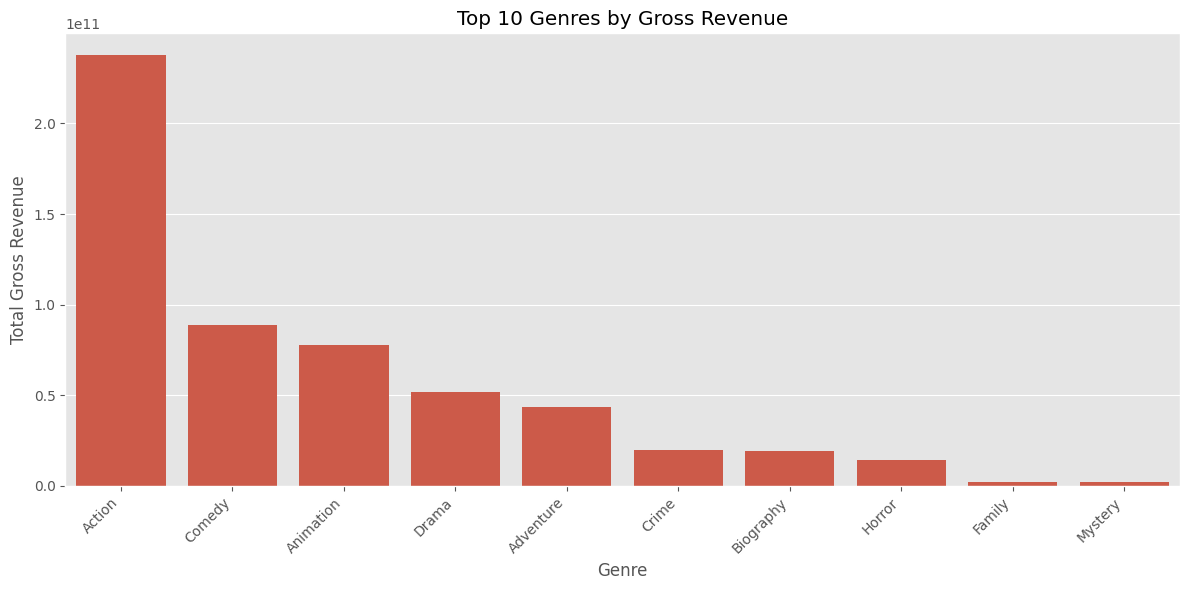

In [ ]:
print('--- Top 10 Genres by Gross Revenue ---')
GenreGrossSum = df.groupby('genre')[["gross"]].sum()
GenreGrossSumSorted = GenreGrossSum.sort_values('gross', ascending=False)[:10]
print(GenreGrossSumSorted)

plt.figure(figsize=(12, 6))
sns.barplot(x=GenreGrossSumSorted.index, y=GenreGrossSumSorted['gross'])
plt.title('Top 10 Genres by Gross Revenue')
plt.xlabel('Genre')
plt.ylabel('Total Gross Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


--- Top 10 Directors by Average Score ---
                    score
director                 
Roberto Benigni      8.60
Tony Kaye            8.50
Bob Persichetti      8.40
Nadine Labaki        8.40
Sergio Leone         8.40
Stanley Kubrick      8.35
Majid Majidi         8.30
Lee Unkrich          8.30
Giuseppe Tornatore   8.30
Thomas Vinterberg    8.20


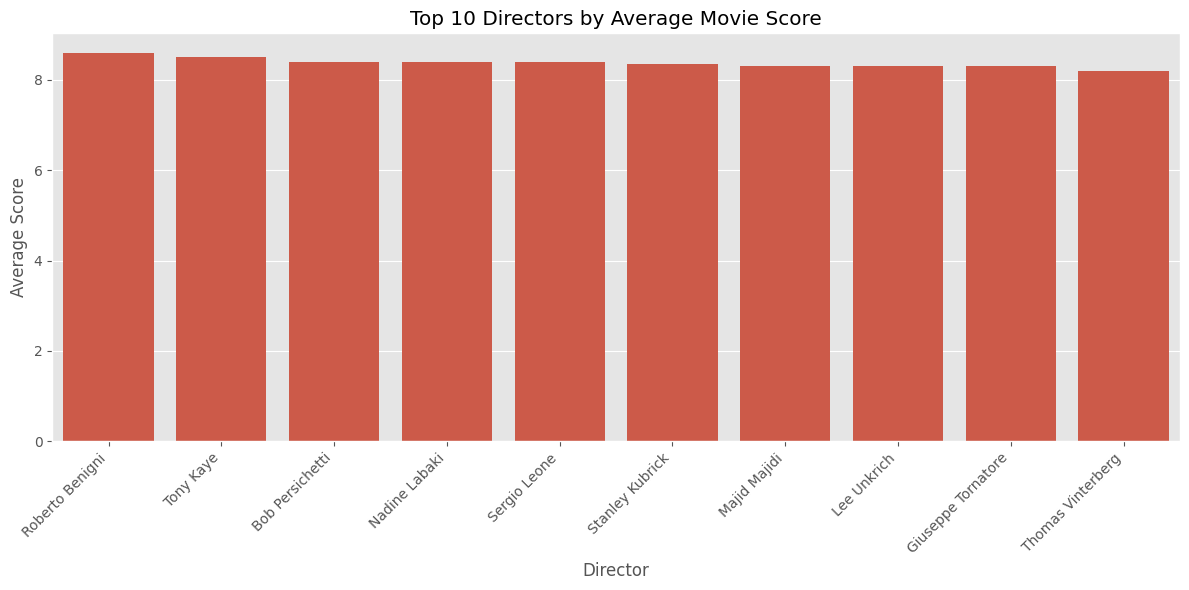

In [ ]:
print('\n--- Top 10 Directors by Average Score ---')
DirectorScoreMean = df.groupby('director')[["score"]].mean()
DirectorScoreMeanSorted = DirectorScoreMean.sort_values('score', ascending=False)[:10]
print(DirectorScoreMeanSorted)

plt.figure(figsize=(12, 6))
sns.barplot(x=DirectorScoreMeanSorted.index, y=DirectorScoreMeanSorted['score'])
plt.title('Top 10 Directors by Average Movie Score')
plt.xlabel('Director')
plt.ylabel('Average Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


--- Top 10 Stars by Average Score ---
                    score
star                     
Philippe Noiret       8.5
Mark Hamill           8.5
Zain Al Rafeea        8.4
Choi Min-sik          8.4
Anthony Gonzalez      8.4
Ben Burtt             8.4
Ulrich Mühe           8.4
F. Murray Abraham     8.3
Mohammad Amir Naji    8.3
Lubna Azabal          8.3


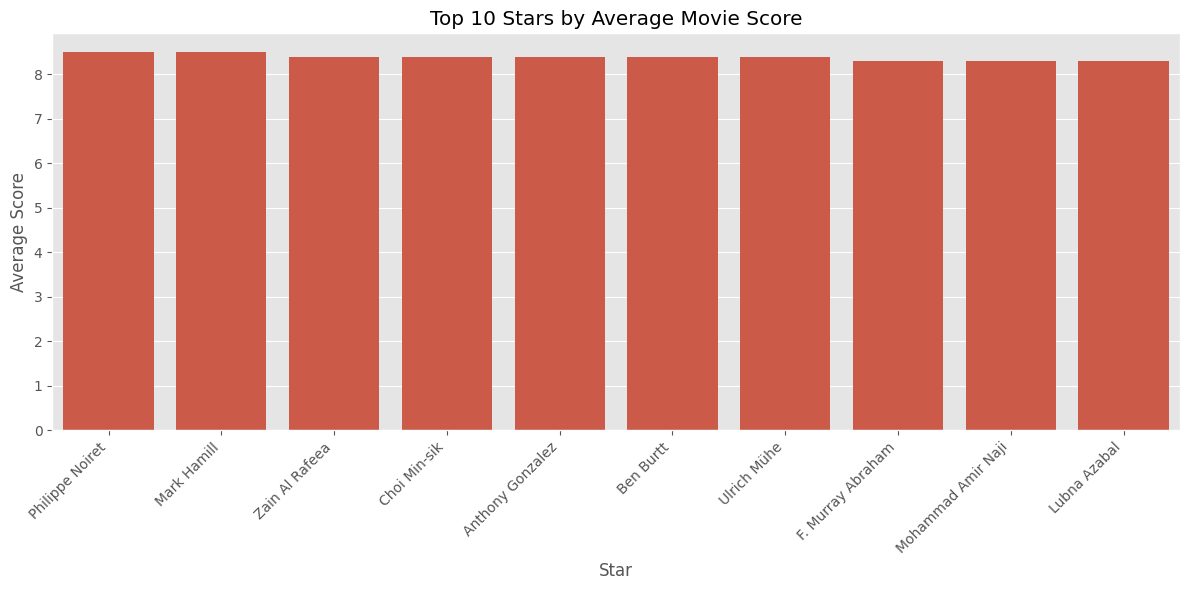

In [ ]:
print('\n--- Top 10 Stars by Average Score ---')
StarScoreMean = df.groupby('star')[["score"]].mean()
StarScoreMeanSorted = StarScoreMean.sort_values('score', ascending=False)[:10]
print(StarScoreMeanSorted)

plt.figure(figsize=(12, 6))
sns.barplot(x=StarScoreMeanSorted.index, y=StarScoreMeanSorted['score'])
plt.title('Top 10 Stars by Average Movie Score')
plt.xlabel('Star')
plt.ylabel('Average Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


--- Top 10 Countries by Average Score ---
                                   score
country                                 
Lebanon                         8.400000
Federal Republic of Yugoslavia  8.100000
Iran                            8.100000
Argentina                       8.066667
Republic of Macedonia           8.000000
Israel                          8.000000
Indonesia                       7.800000
India                           7.762500
Taiwan                          7.633333
Brazil                          7.533333


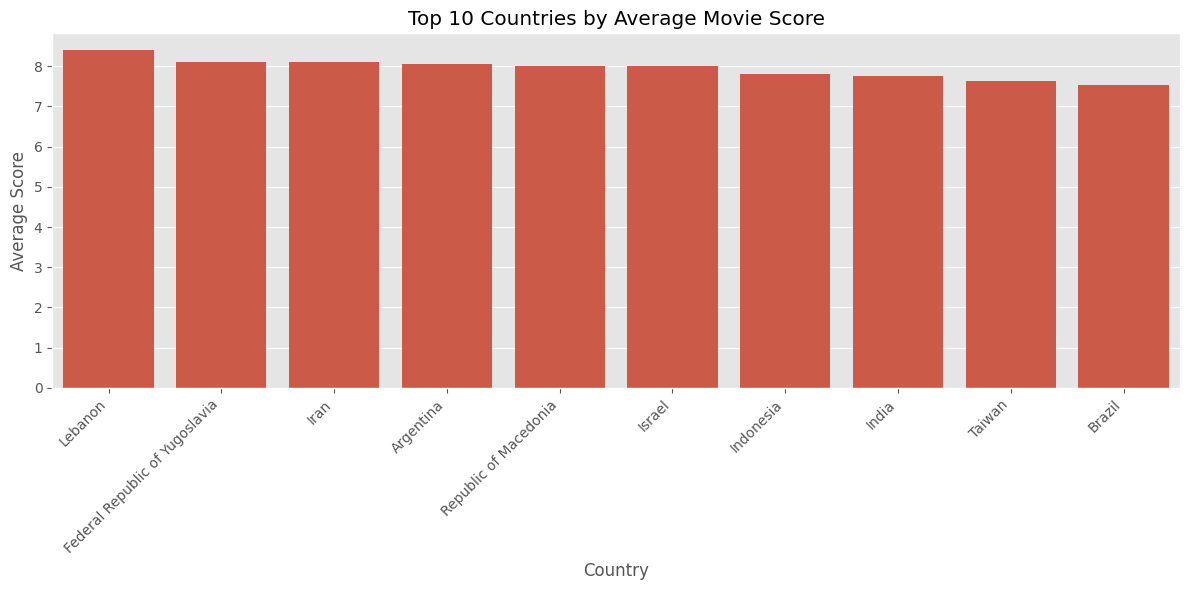

In [ ]:
print('\n--- Top 10 Countries by Average Score ---')
CountryScoreMean = df.groupby('country')[["score"]].mean()
CountryScoreMeanSorted = CountryScoreMean.sort_values('score', ascending=False)[:10]
print(CountryScoreMeanSorted)

plt.figure(figsize=(12, 6))
sns.barplot(x=CountryScoreMeanSorted.index, y=CountryScoreMeanSorted['score'])
plt.title('Top 10 Countries by Average Movie Score')
plt.xlabel('Country')
plt.ylabel('Average Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


--- Relationship between Runtime and Gross Earnings ---


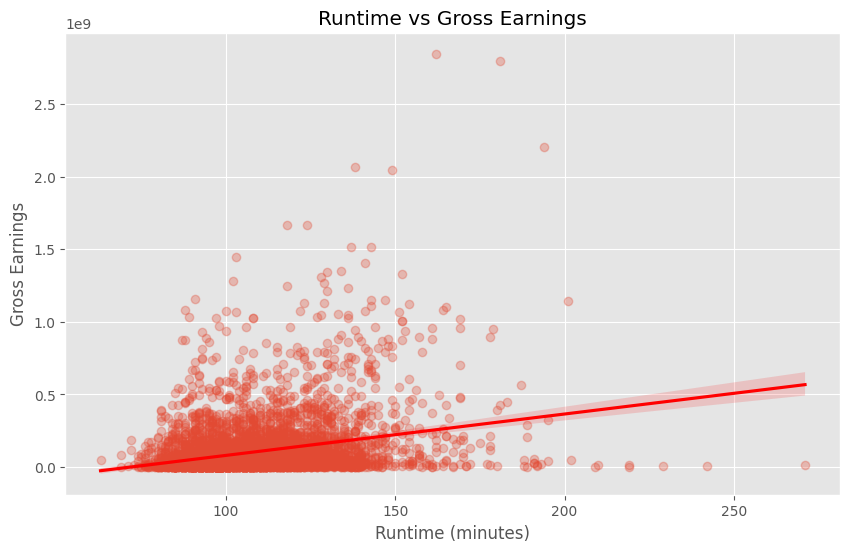


Correlation between Runtime and Gross Earnings:
          runtime     gross
runtime  1.000000  0.275796
gross    0.275796  1.000000


In [ ]:
print('\n--- Relationship between Runtime and Gross Earnings ---')
plt.figure(figsize=(10, 6))
sns.regplot(x='runtime', y='gross', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Runtime vs Gross Earnings')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Gross Earnings')
plt.show()

print('\nCorrelation between Runtime and Gross Earnings:')
print(df[['runtime', 'gross']].corr(method='pearson'))


--- Relationship between Score and Gross Earnings ---


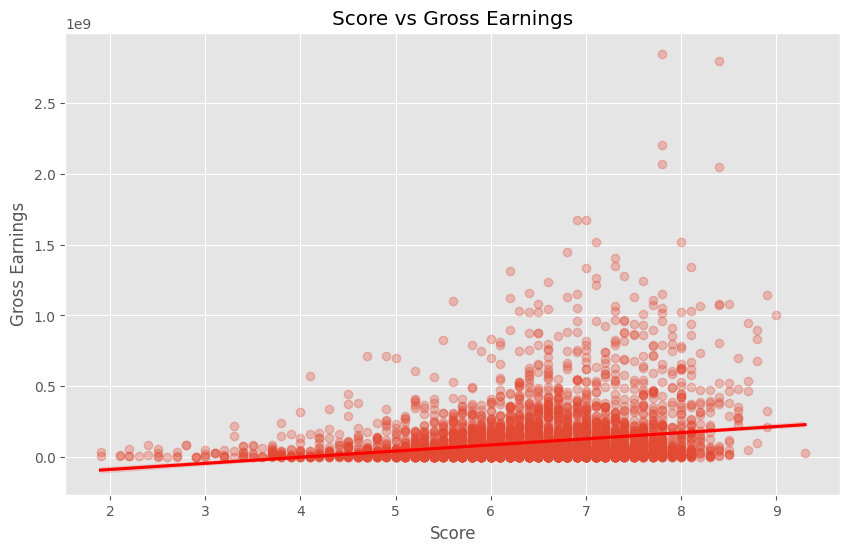

Correlation between Score and Gross Earnings:
          score     gross
score  1.000000  0.222556
gross  0.222556  1.000000


In [ ]:
print('\n--- Relationship between Score and Gross Earnings ---')
plt.figure(figsize=(10, 6))
sns.regplot(x='score', y='gross', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Score vs Gross Earnings')
plt.xlabel('Score')
plt.ylabel('Gross Earnings')
plt.show()

print('Correlation between Score and Gross Earnings:')
print(df[['score', 'gross']].corr(method='pearson'))

A correlation close to 0 indicates a weak linear relationship. A positive value indicates that as one variable increases, the other tends to increase, while a negative value indicates that as one variable increases, the other tends to decrease. The closer the value is to 1 or -1, the stronger the linear relationship.


--- Trends over years: Average Gross and Average Score ---


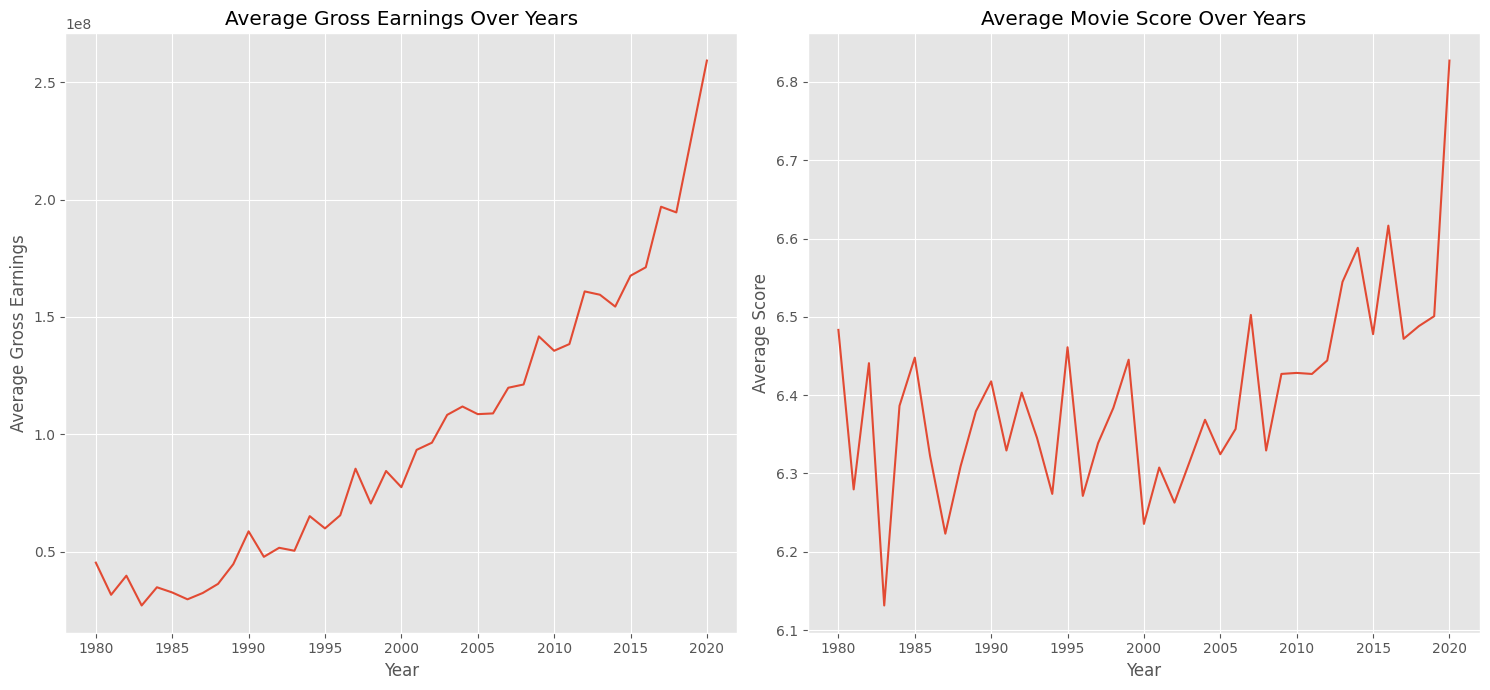

In [ ]:
print('\n--- Trends over years: Average Gross and Average Score ---')
yearly_stats = df.groupby('yearcorrect')[['gross', 'score']].mean().reset_index()
yearly_stats['yearcorrect'] = yearly_stats['yearcorrect'].astype(int)

plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
sns.lineplot(x='yearcorrect', y='gross', data=yearly_stats)
plt.title('Average Gross Earnings Over Years')
plt.xlabel('Year')
plt.ylabel('Average Gross Earnings')

plt.subplot(1, 2, 2)
sns.lineplot(x='yearcorrect', y='score', data=yearly_stats)
plt.title('Average Movie Score Over Years')
plt.xlabel('Year')
plt.ylabel('Average Score')

plt.tight_layout()
plt.show()



--- Top 10 Writers by Average Score ---
                    score
writer                   
Thomas Keneally     8.900
Chuck Palahniuk     8.800
Winston Groom       8.800
J.R.R. Tolkien      8.800
Leigh Brackett      8.700
Jonathan Nolan      8.625
Vincenzo Cerami     8.600
Giuseppe Tornatore  8.500
Irene Mecchi        8.500
David McKenna       8.500


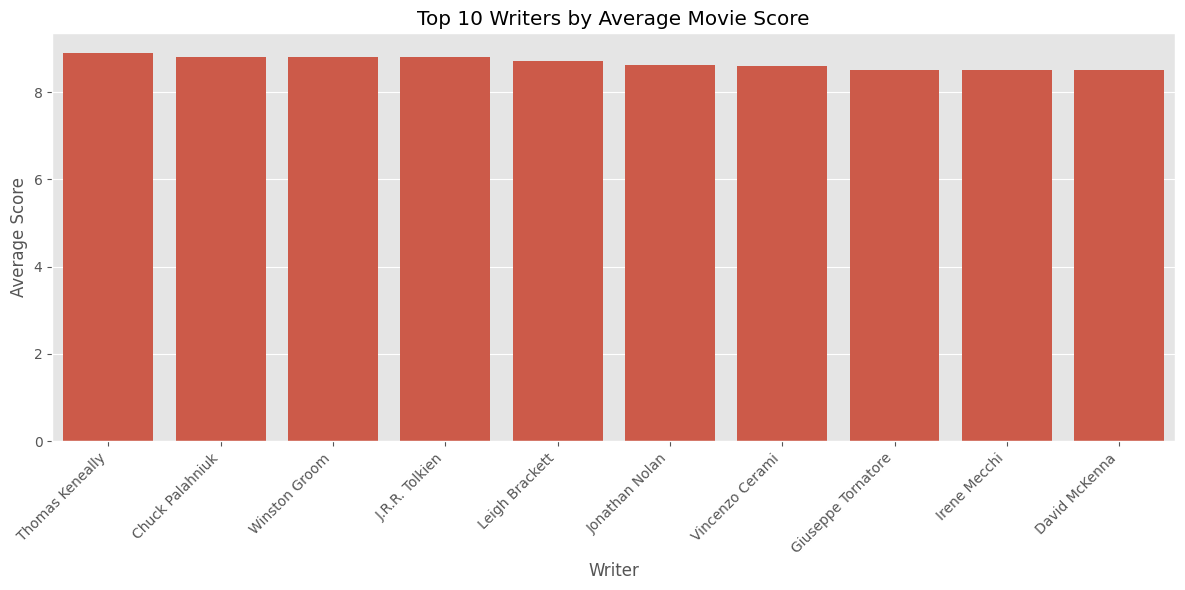

In [ ]:
print('\n--- Top 10 Writers by Average Score ---')
WriterScoreMean = df.groupby('writer')[["score"]].mean()
WriterScoreMeanSorted = WriterScoreMean.sort_values('score', ascending=False)[:10]
print(WriterScoreMeanSorted)

plt.figure(figsize=(12, 6))
sns.barplot(x=WriterScoreMeanSorted.index, y=WriterScoreMeanSorted['score'])
plt.title('Top 10 Writers by Average Movie Score')
plt.xlabel('Writer')
plt.ylabel('Average Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


--- Movie Genre vs. Average Score ---
              score
genre              
Biography  7.088103
Drama      6.721437
Animation  6.690614
Crime      6.689223
Family     6.675000
Mystery    6.670588
Romance    6.580000
Sci-Fi     6.350000
Adventure  6.268196
Action     6.247350
Comedy     6.190709
Fantasy    6.048780
Western    5.950000
Thriller   5.928571
Horror     5.827490


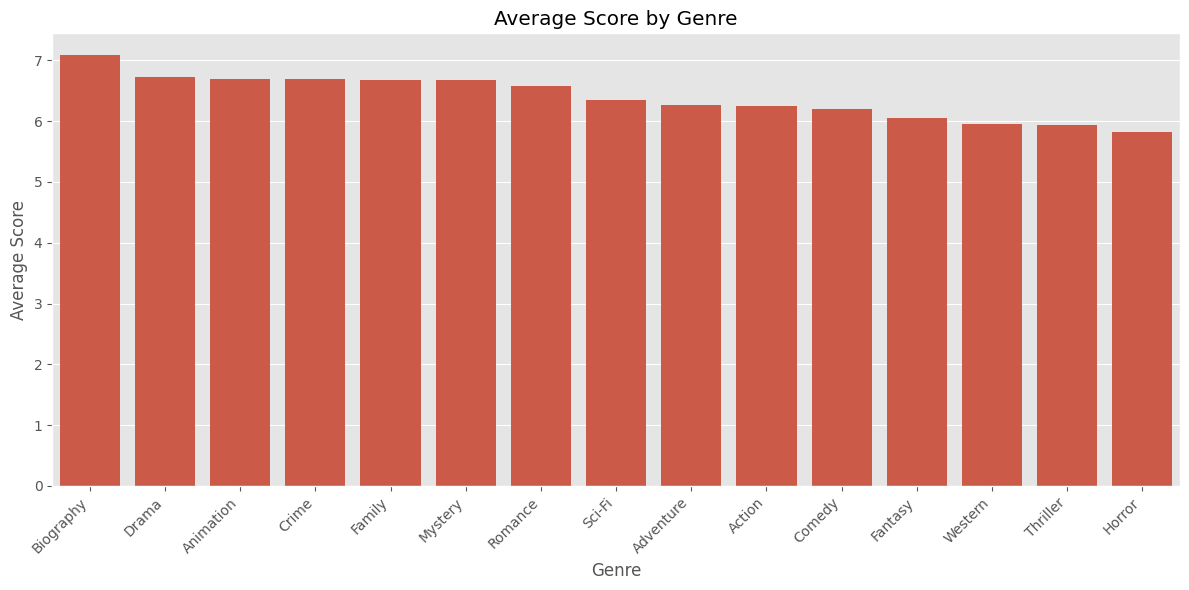

In [ ]:
print('\n--- Movie Genre vs. Average Score ---')
GenreScoreMean = df.groupby('genre')[['score']].mean().sort_values(by='score', ascending=False)
print(GenreScoreMean)

plt.figure(figsize=(12, 6))
sns.barplot(x=GenreScoreMean.index, y=GenreScoreMean['score'])
plt.title('Average Score by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


--- Movie Genre vs. Average Runtime ---
              runtime
genre                
Biography  121.874598
Mystery    117.235294
Drama      115.117034
Crime      112.969925
Action     111.197880
Family     109.750000
Adventure  109.107034
Romance    108.400000
Comedy     102.108957
Sci-Fi     101.333333
Western    100.500000
Fantasy    100.268293
Thriller    97.714286
Horror      96.617530
Animation   91.570397


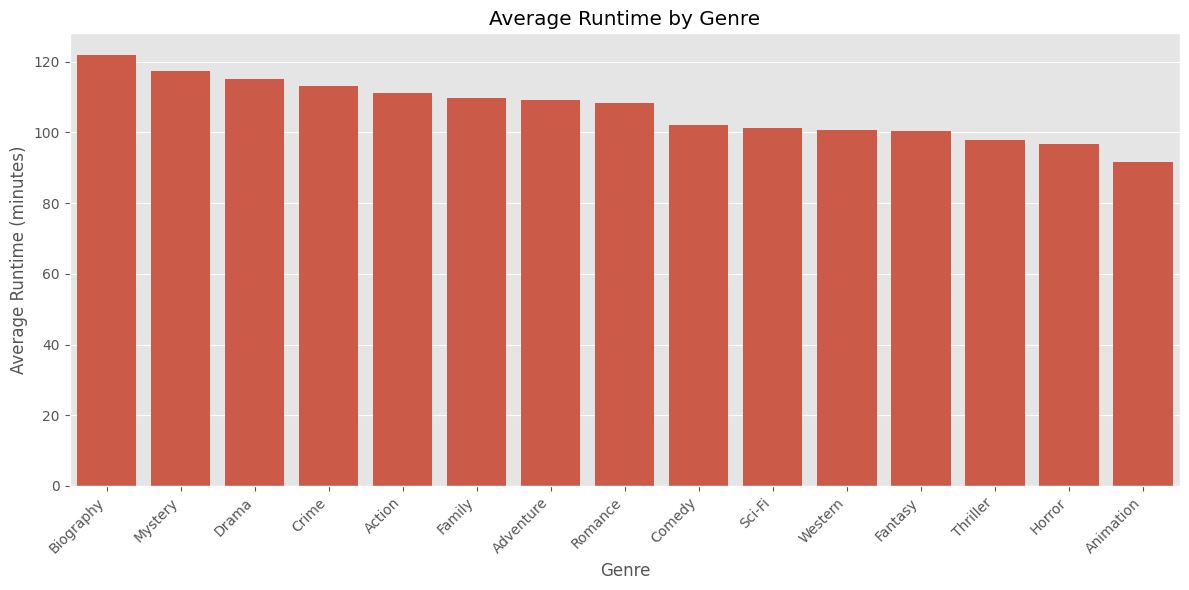

In [ ]:
print('\n--- Movie Genre vs. Average Runtime ---')
GenreRuntimeMean = df.groupby('genre')[['runtime']].mean().sort_values(by='runtime', ascending=False)
print(GenreRuntimeMean)

plt.figure(figsize=(12, 6))
sns.barplot(x=GenreRuntimeMean.index, y=GenreRuntimeMean['runtime'])
plt.title('Average Runtime by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Runtime (minutes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


--- Top 10 Countries by Total Gross Revenue ---
                       gross
country                     
United States   470794726099
United Kingdom   45351705966
France            6568533115
China             6305918953
New Zealand       6278354563
Canada            5734558085
Germany           5688083409
Australia         2800304264
Japan             2494214085
Hong Kong         1412222241


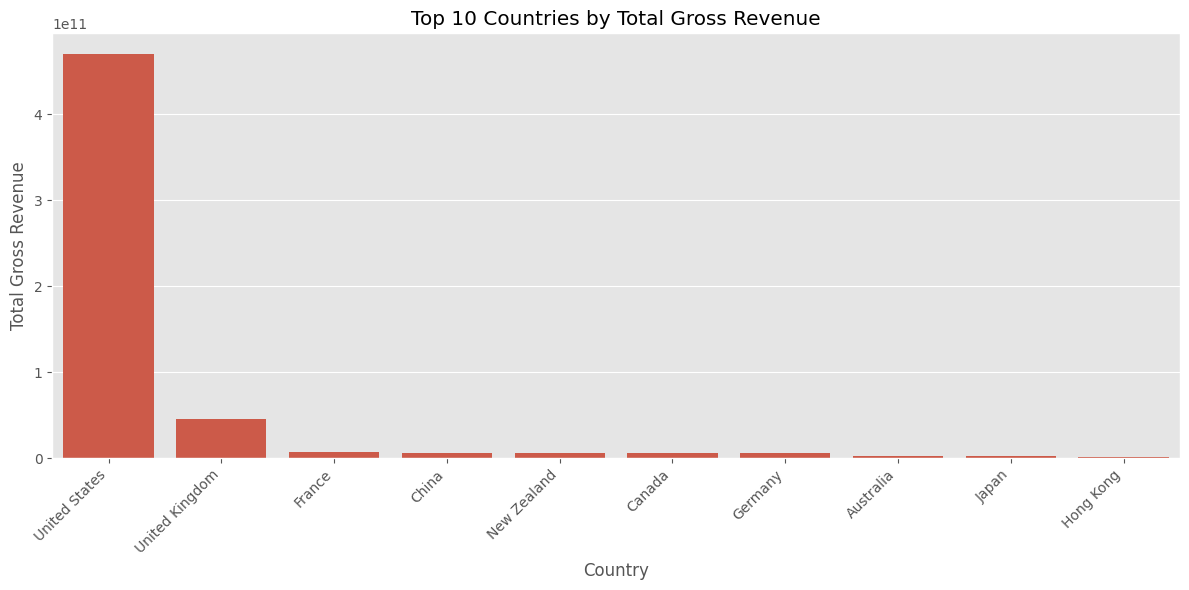

In [ ]:
print('\n--- Top 10 Countries by Total Gross Revenue ---')
CountryGrossSum = df.groupby('country')[['gross']].sum().sort_values(by='gross', ascending=False)[:10]
print(CountryGrossSum)

plt.figure(figsize=(12, 6))
sns.barplot(x=CountryGrossSum.index, y=CountryGrossSum['gross'])
plt.title('Top 10 Countries by Total Gross Revenue')
plt.xlabel('Country')
plt.ylabel('Total Gross Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
movies_per_country = df['country'].value_counts()
display(movies_per_country)

,count
country,
United States,4319
United Kingdom,492
Canada,111
France,105
Germany,82
Australia,42
Japan,28
China,26
Hong Kong,24


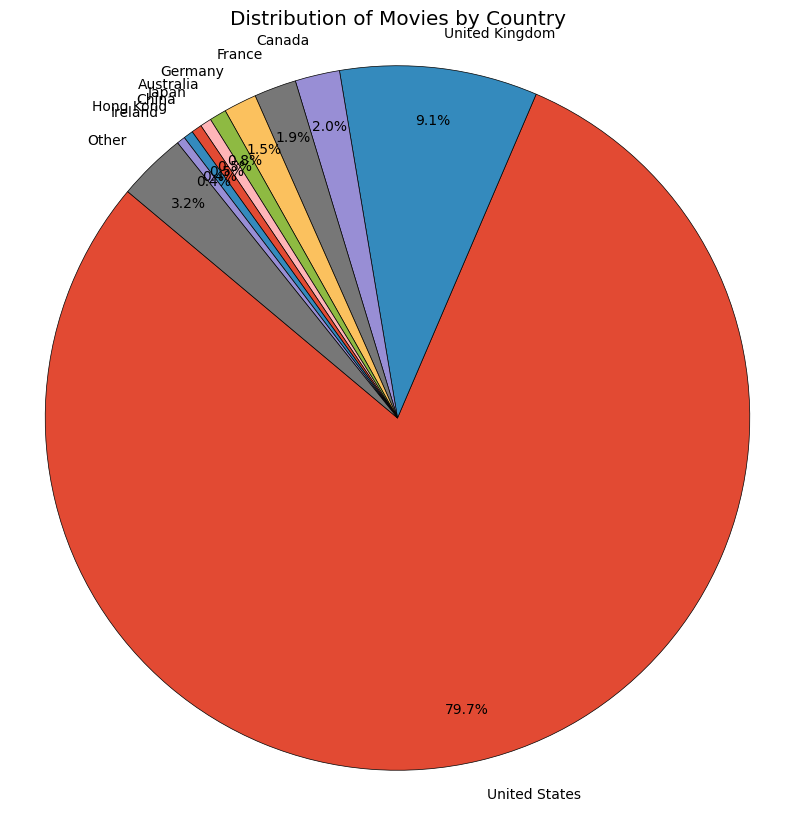

In [ ]:
plt.figure(figsize=(10, 10))

# Get top N countries and group the rest into 'Other'
top_n = 10
labels = movies_per_country.head(top_n).index.tolist()
sizes = movies_per_country.head(top_n).values.tolist()

# Add 'Other' category
other_count = movies_per_country.iloc[top_n:].sum()
if other_count > 0:
    labels.append('Other')
    sizes.append(other_count)

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, pctdistance=0.85, wedgeprops={'edgecolor': 'black'})
plt.title('Distribution of Movies by Country')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [ ]:
movies_per_country.Austria

np.int64(2)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Let's use the numerized DataFrame for ML, as categorical features are encoded
# We'll try to predict 'gross' earnings

X = df_numerized.drop(['gross', 'name', 'released'], axis=1) # Features, dropping target and string columns
y = df_numerized['gross'] # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)



Features (X) shape: (5421, 13)
Target (y) shape: (5421,)
X_train shape: (4336, 13)
X_test shape: (1085, 13)
y_train shape: (4336,)
y_test shape: (1085,)


In [ ]:
# Initialize and train a Linear Regression model (a simple example)
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Note: This is a very basic model. Further steps like feature scaling, more advanced models,
# and hyperparameter tuning would be needed for a robust machine learning solution.


Mean Squared Error: 1.102704784895491e+16
R-squared: 0.6777803331930234
